In [1]:
# Importing imporant libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import TimeSeriesSplit

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, SimpleRNN, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

import warnings
warnings.filterwarnings('ignore')
plt.style.use('fivethirtyeight')

In [2]:
# Loading the data

df = pd.read_csv('AAPL.csv')
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,1980-12-12,0.513393,0.515625,0.513393,0.513393,0.407747,117258400.0
1,1980-12-15,0.488839,0.488839,0.486607,0.486607,0.386473,43971200.0
2,1980-12-16,0.453125,0.453125,0.450893,0.450893,0.358108,26432000.0
3,1980-12-17,0.462054,0.464286,0.462054,0.462054,0.366972,21610400.0
4,1980-12-18,0.475446,0.477679,0.475446,0.475446,0.377609,18362400.0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9823 entries, 0 to 9822
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       9823 non-null   object 
 1   Open       9822 non-null   float64
 2   High       9822 non-null   float64
 3   Low        9822 non-null   float64
 4   Close      9822 non-null   float64
 5   Adj Close  9822 non-null   float64
 6   Volume     9822 non-null   float64
dtypes: float64(6), object(1)
memory usage: 537.3+ KB


In [4]:
# Clean column names 
df.columns = df.columns.str.strip().str.lower()
print("\nCleaned Columns:", df.columns.tolist())


Cleaned Columns: ['date', 'open', 'high', 'low', 'close', 'adj close', 'volume']


In [5]:
# Convert the 'date' column to datetime format
df['date'] = pd.to_datetime(df['date'])

In [6]:
df.isnull().sum()

date         0
open         1
high         1
low          1
close        1
adj close    1
volume       1
dtype: int64

In [7]:
df = df.sort_values('date') # Ensure chronological order before filling
df = df.interpolate(method='linear')

In [8]:
# Set indexes
df.set_index('date', inplace=True)

In [12]:
# EXPLORATORY DATA ANALYSIS & VISUALIZATION

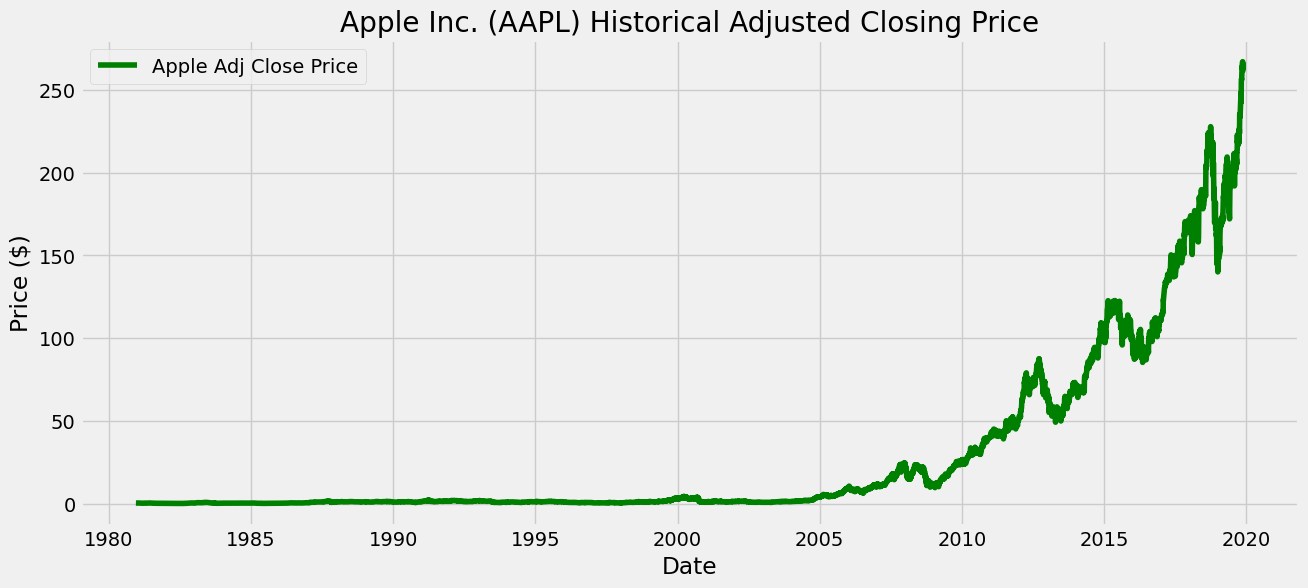

In [9]:
# Plot the Historical Adjusted Closing Price
plt.figure(figsize=(14, 6))
plt.plot(df['adj close'], label='Apple Adj Close Price', color='apple_green' if 'apple_green' in plt.cm.datad else 'green')
plt.title('Apple Inc. (AAPL) Historical Adjusted Closing Price')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.legend()
plt.show()

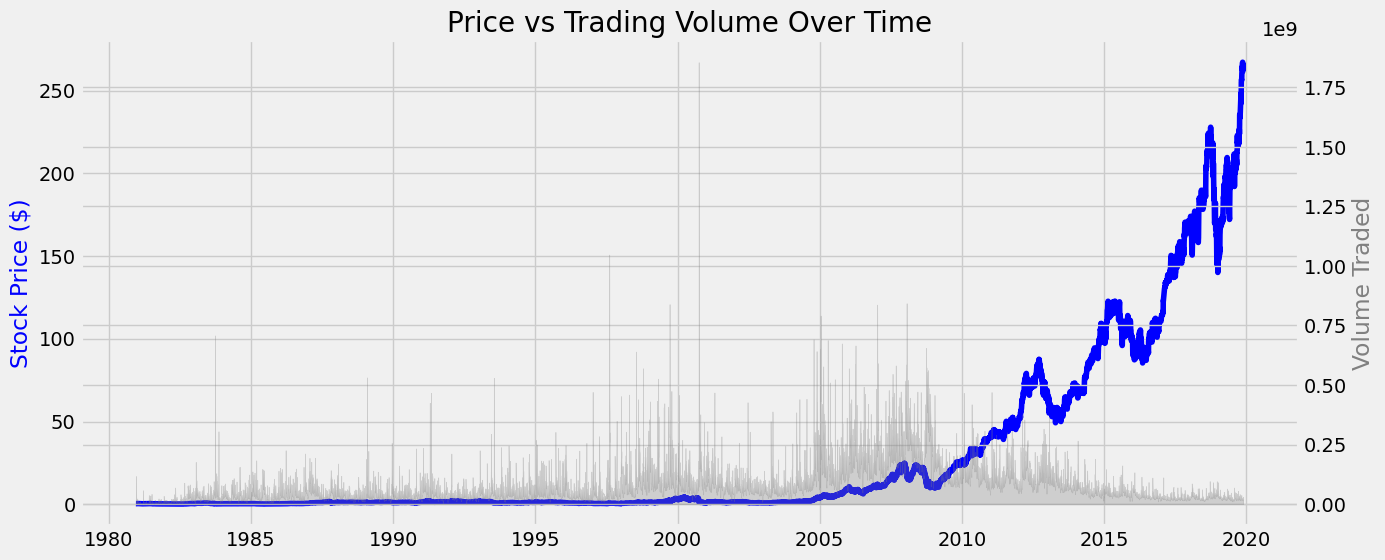

In [10]:
# Plot Volume and Adj Close to look for trends
fig, ax1 = plt.subplots(figsize=(14, 6))
ax1.plot(df['adj close'], color='blue', label='Adj Close')
ax1.set_ylabel('Stock Price ($)', color='blue')
ax2 = ax1.twinx()
ax2.fill_between(df.index, df['volume'], color='gray', alpha=0.3, label='Volume')
ax2.set_ylabel('Volume Traded', color='gray')
plt.title('Price vs Trading Volume Over Time')
plt.show()

In [11]:
# DATA PRE-PROCESSING & FEATURE ENGINEERING

In [13]:
# Extract the target series (Adjusted Closing Price)
target_data = df[['adj close']].values

In [14]:
# Scale data to range (0, 1) using MinMaxScaler for neural network stability
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(target_data)

In [15]:
def create_sequences(data, window_size, horizon):

    X, y = [], []
    for i in range(len(data) - window_size - horizon + 1):
        X.append(data[i : (i + window_size)])
        # Target is the specific step at the end of the horizon window
        y.append(data[i + window_size + horizon - 1])
    return np.array(X), np.array(y)

In [ ]:
"""
    Creates input features (X) and target labels (y) for sequential training.
    
    Parameters:
    - data: Scaled time-series array
    - window_size: Number of past days to look back (e.g., 60 days)
    - horizon: Number of days into the future to predict (1, 5, or 10 days)
    """

In [17]:
WINDOW_SIZE = 60  # Look back 60 business days (~3 months)
HORIZON = 1       # Change to 5 or 10 to train the respective models

X, y = create_sequences(scaled_data, window_size=WINDOW_SIZE, horizon=HORIZON)

In [18]:
# Train-Test Split (Chronological, NO shuffling to prevent data leakage)
train_size = int(len(X) * 0.8)

X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

print(f"\nSequence Shapes for Horizon = {HORIZON}:")
print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_test: {X_test.shape}, y_test: {y_test.shape}")


Sequence Shapes for Horizon = 1:
X_train: (7810, 60, 1), y_train: (7810, 1)
X_test: (1953, 60, 1), y_test: (1953, 1)


In [19]:
# DL MODELING: SimpleRNN vs LSTM

In [20]:
# SimpleRNN Model Builder

def build_rnn_model(input_shape):
    model = Sequential([
        SimpleRNN(units=50, return_sequences=True, input_shape=input_shape),
        Dropout(0.2),
        SimpleRNN(units=50, return_sequences=False),
        Dropout(0.2),
        Dense(units=25),
        Dense(units=1)
    ])
    model.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error')
    return model

In [22]:
# LSTM Model Builder

def build_lstm_model(input_shape):
    model = Sequential([
        LSTM(units=50, return_sequences=True, input_shape=input_shape),
        Dropout(0.2),
        LSTM(units=50, return_sequences=False),
        Dropout(0.2),
        Dense(units=25),
        Dense(units=1)
    ])
    model.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error')
    return model

In [24]:
# Set up global deep learning metrics/callbacks
callbacks = [
    EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True),
    ModelCheckpoint('best_model.keras', monitor='val_loss', save_best_only=True)
]

In [25]:
# Training SimpleRNN

print("\n--- Training SimpleRNN Model ---")
rnn_model = build_rnn_model((X_train.shape[1], 1))
rnn_history = rnn_model.fit(
    X_train, y_train, 
    epochs=20, 
    batch_size=32, 
    validation_split=0.1, 
    callbacks=callbacks,
    verbose=1
)


--- Training SimpleRNN Model ---
Epoch 1/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 0.0017 - val_loss: 5.1811e-04
Epoch 2/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 1.1191e-04 - val_loss: 4.8272e-05
Epoch 3/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 6.8271e-05 - val_loss: 6.1134e-05
Epoch 4/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 4.0402e-05 - val_loss: 2.9411e-04
Epoch 5/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 3.2866e-05 - val_loss: 7.8712e-05
Epoch 6/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 2.1914e-05 - val_loss: 1.4247e-04
Epoch 7/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 2.0753e-05 - val_loss: 1.0522e-04
Epoch 8/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 1.5567e-05 - val_loss: 1.9202e-04
Epoch 9/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 1.6229e-05 - val_loss: 6.8740e-05


In [26]:
# Train LSTM 
print("\n--- Training LSTM Model ---")
lstm_model = build_lstm_model((X_train.shape[1], 1))
lstm_history = lstm_model.fit(
    X_train, y_train, 
    epochs=20, 
    batch_size=32, 
    validation_split=0.1, 
    callbacks=callbacks,
    verbose=1
)


--- Training LSTM Model ---
Epoch 1/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 9s 32ms/step - loss: 2.0023e-05 - val_loss: 6.8266e-05
Epoch 2/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 7s 31ms/step - loss: 5.5589e-06 - val_loss: 3.9429e-05
Epoch 3/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 7s 31ms/step - loss: 6.4547e-06 - val_loss: 2.6712e-05
Epoch 4/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step - loss: 6.0055e-06 - val_loss: 8.6742e-05
Epoch 5/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step - loss: 5.5372e-06 - val_loss: 6.7590e-05
Epoch 6/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 7s 31ms/step - loss: 4.6188e-06 - val_loss: 2.3369e-05
Epoch 7/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step - loss: 5.9442e-06 - val_loss: 1.6160e-04
Epoch 8/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step - loss: 4.6886e-06 - val_loss: 5.0675e-05
Epoch 9/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step - loss: 5.0441e-06 - val_loss: 4.5478e-05
Epoch 10/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step - loss: 5.7745e-06 - val_loss: 3.4435e-05
Epoch 11/20
220/220 

In [27]:
# MODEL OPTIMIZATION: Hyperparameter Tuning

def manual_grid_search(X_tr, y_tr):
    print("\n--- Starting Manual Hyperparameter Tuning for LSTM ---")
    best_loss = float('inf')
    best_params = {}
    
    # Grid space
    units_opts = [50, 100]
    dropout_opts = [0.1, 0.2]
    lr_opts = [0.001, 0.01]
    
    for u in units_opts:
        for d in dropout_opts:
            for lr in lr_opts:
                print(f"Testing Config -> Units: {u}, Dropout: {d}, LR: {lr}")
                model = Sequential([
                    LSTM(units=u, return_sequences=False, input_shape=(X_tr.shape[1], 1)),
                    Dropout(d),
                    Dense(1)
                ])
                model.compile(optimizer=Adam(learning_rate=lr), loss='mean_squared_error')
                
                # Fast evaluation fit
                hist = model.fit(X_tr, y_tr, epochs=5, batch_size=64, validation_split=0.1, verbose=0)
                val_loss = min(hist.history['val_loss'])
                
                if val_loss < best_loss:
                    best_loss = val_loss
                    best_params = {'units': u, 'dropout': d, 'lr': lr}
                    
    print(f"Optimal Hyperparameters Discovered: {best_params} with Val Loss: {best_loss}")
    return best_params

In [28]:
# Execute Grid Search
best_hparams = manual_grid_search(X_train, y_train)


--- Starting Manual Hyperparameter Tuning for LSTM ---
Testing Config -> Units: 50, Dropout: 0.1, LR: 0.001
Testing Config -> Units: 50, Dropout: 0.1, LR: 0.01
Testing Config -> Units: 50, Dropout: 0.2, LR: 0.001
Testing Config -> Units: 50, Dropout: 0.2, LR: 0.01
Testing Config -> Units: 100, Dropout: 0.1, LR: 0.001
Testing Config -> Units: 100, Dropout: 0.1, LR: 0.01
Testing Config -> Units: 100, Dropout: 0.2, LR: 0.001
Testing Config -> Units: 100, Dropout: 0.2, LR: 0.01
Optimal Hyperparameters Discovered: {'units': 100, 'dropout': 0.1, 'lr': 0.01} with Val Loss: 1.0258077963953838e-05


In [29]:
# MODEL EVALUATION & PREDICTION

In [30]:
# Run predictions on the test partition
rnn_preds = rnn_model.predict(X_test)
lstm_preds = lstm_model.predict(X_test)

62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step


In [31]:
# Invert Scaling to transform back to true USD Dollar value representation
y_test_real = scaler.inverse_transform(y_test)
rnn_preds_real = scaler.inverse_transform(rnn_preds)
lstm_preds_real = scaler.inverse_transform(lstm_preds)

In [32]:
# Calculate Evaluation Metrics
metrics_summary = {
    "Model": ["SimpleRNN", "LSTM"],
    "MAE": [mean_absolute_error(y_test_real, rnn_preds_real), mean_absolute_error(y_test_real, lstm_preds_real)],
    "MSE": [mean_squared_error(y_test_real, rnn_preds_real), mean_squared_error(y_test_real, lstm_preds_real)],
    "R² Score": [r2_score(y_test_real, rnn_preds_real), r2_score(y_test_real, lstm_preds_real)]
}

In [33]:
metrics_df = pd.DataFrame(metrics_summary)
print("\n--- Final Performance Comparison ---")
print(metrics_df.to_string(index=False))


--- Final Performance Comparison ---
    Model       MAE         MSE  R² Score
SimpleRNN 38.603592 3172.753040 -0.261835
     LSTM  3.334111   23.520263  0.990646


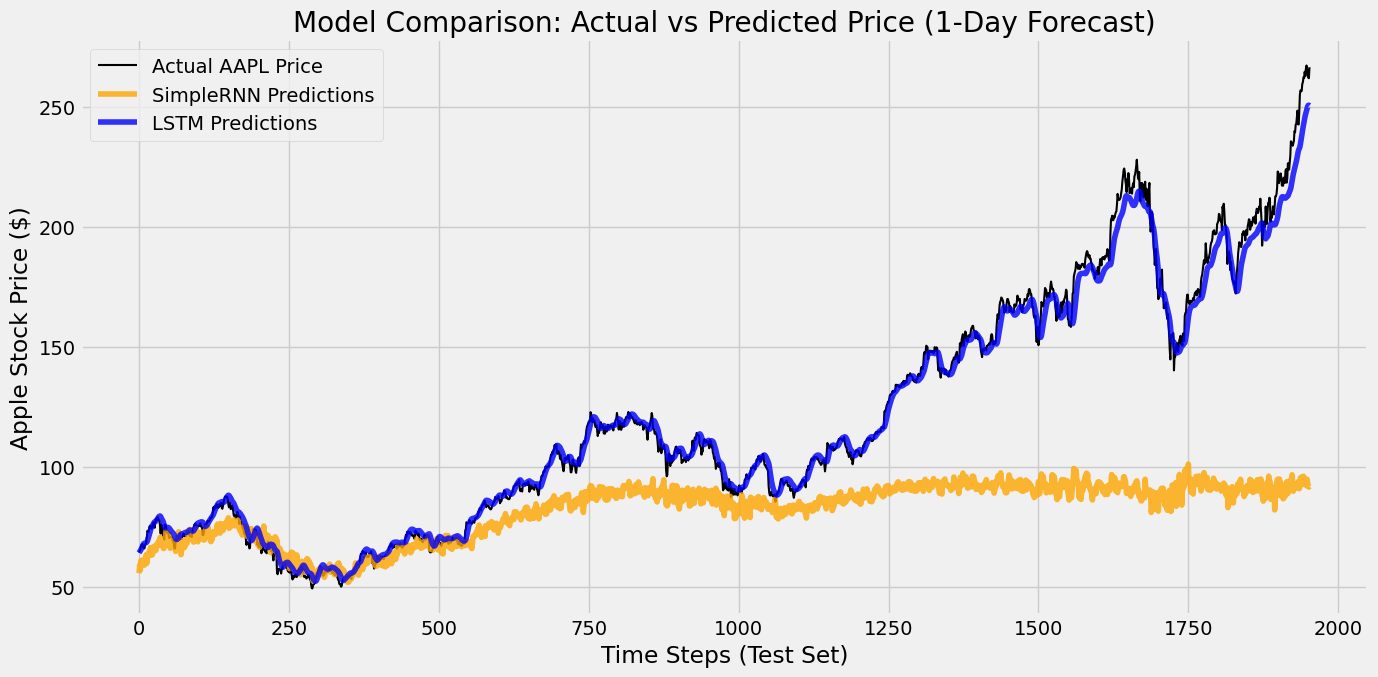

In [34]:
# Visualize Model Predictions Against Actuals

plt.figure(figsize=(14, 7))
plt.plot(y_test_real, label='Actual AAPL Price', color='black', linewidth=1.5)
plt.plot(rnn_preds_real, label='SimpleRNN Predictions', color='orange', alpha=0.8)
plt.plot(lstm_preds_real, label='LSTM Predictions', color='blue', alpha=0.8)
plt.title(f'Model Comparison: Actual vs Predicted Price ({HORIZON}-Day Forecast)')
plt.xlabel('Time Steps (Test Set)')
plt.ylabel('Apple Stock Price ($)')
plt.legend()
plt.tight_layout()
plt.show()